In [1]:
# Import the dependencies
import pandas as pd
import numpy as np
import datetime
# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
# ORM Stuff
from sqlalchemy import create_engine, inspect, text, func
from sqlalchemy.orm import Session
from sqlalchemy.ext.automap import automap_base

In [2]:
USERNAME = "postgres"
PASSWORD = "postgres"
HOST = "localhost"
PORT = 5432
DATABASE = "Project_2_DB"
connection_str = f"postgresql://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
# Create Engine
engine = create_engine(connection_str)

In [3]:
# Create the inspector and connect it to the engine
inspector = inspect(engine)
# Collect the names of tables within the database
tables = inspector.get_table_names()
# Using the inspector to print the column names within the 'dow' table and its types
for table in tables:
    print(table)
    print("--------")
    columns = inspector.get_columns(table)
    for column in columns:
        print(column["name"], column["type"])
    print()

contacts
--------
contact_id INTEGER
first_name VARCHAR(20)
last_name VARCHAR(20)
email VARCHAR(60)

campaign
--------
cf_id INTEGER
contact_id INTEGER
company_name VARCHAR(50)
description VARCHAR(55)
goal INTEGER
pledged INTEGER
outcome VARCHAR(10)
backers_count INTEGER
country VARCHAR(2)
currency VARCHAR(3)
launch_date DATE
end_date DATE
category_id VARCHAR(5)
subcategory_id VARCHAR(8)

categories
--------
category_id VARCHAR(5)
category VARCHAR(25)

subcategories
--------
subcategory_id VARCHAR(8)
subcategory VARCHAR(25)



In [8]:
conn = engine.connect()

In [10]:
conn.execute(text("""SELECT 
                    	c.description,
                    	c.backers_count
                    FROM 
                    	campaign as c
                    WHERE
                    	company_name like 'Davis Ltd'""")).all()

[('Grass-roots optimizing projection', 803),
 ('Synchronized motivating solution', 363),
 ('Upgradable uniform service-desk', 100)]

In [12]:
query_df = pd.read_sql("""SELECT 
                    	c.description,
                    	c.backers_count
                    FROM 
                    	campaign as c
                    WHERE
                    	company_name like 'Davis Ltd'""",
                      conn)
query_df.head()

,description,backers_count
0,Grass-roots optimizing projection,803
1,Synchronized motivating solution,363
2,Upgradable uniform service-desk,100


In [19]:
average_backers_count = query_df.backers_count.mean()         
average_backers_count


422.0

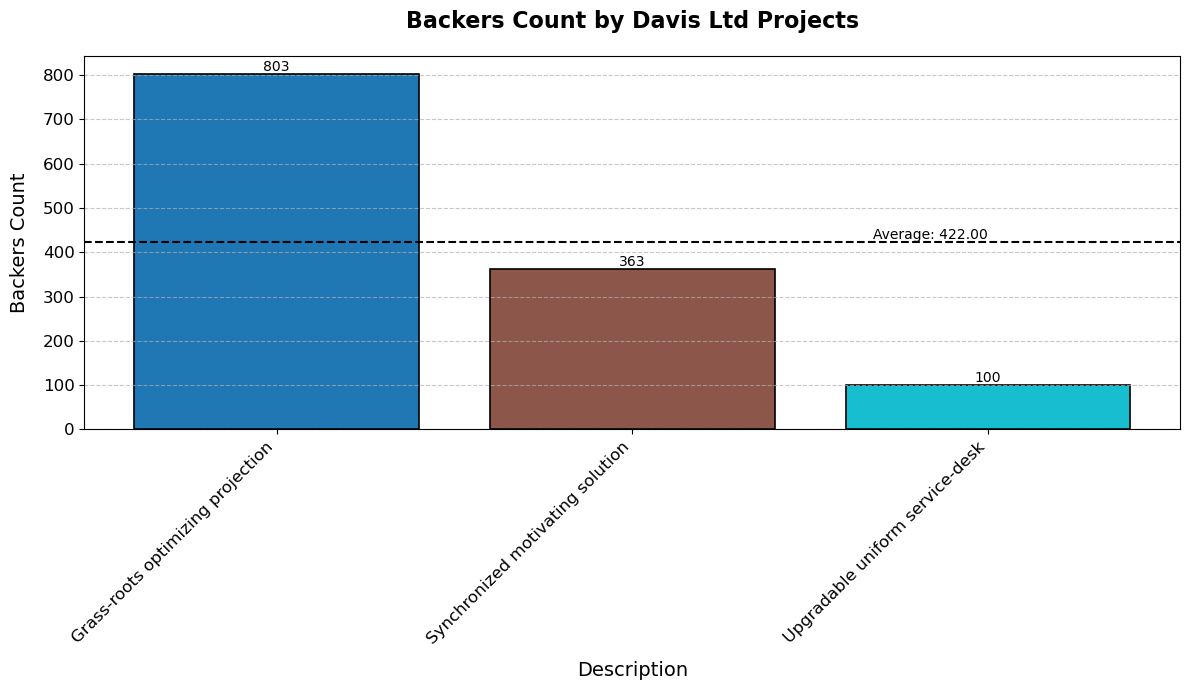

In [36]:
colors = plt.cm.tab10(np.linspace(0, 1, len(query_df.description))) # (Borrowed code from Seven)
# Bar chart of total pledged by category
plt.figure(figsize=(12, 7))
# Customizing the bar plot with colors
bars = plt.bar(
    query_df.description,
    query_df.backers_count,
    color=colors,  # Assign the color palette
    edgecolor='black',
    linewidth=1.2
)
# Add value labels to each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

# Average line from Xpert AI
# Calculate the average value
average_value = average_backers_count

# Add a horizontal line for the average
plt.axhline(y=average_value, color='black', linestyle='--', label='Average')

# Add a label for the average line
plt.text(x=len(query_df.description)-1, y=average_value, s='Average: {:.2f}'.format(average_value), 
         color='black', va='bottom', ha='right')

# Customizing titles and labels
plt.title('Backers Count by Davis Ltd Projects', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Description', fontsize=14, labelpad=10)
plt.ylabel('Backers Count', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
# Adding gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Adjust layout for better spacing
plt.tight_layout()
# Save the chart as an image file
plt.savefig('Backers_Count_by_Davis_Ltd_Projects.png', dpi=300, bbox_inches='tight')
# Display the chart
plt.show()